<a href="https://colab.research.google.com/github/nourjamal4488-cell/FDS_Midterm_Alt/blob/main/Midterm_Alt_Nour_u25104814.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.


# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [1]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.2 MB/s eta 0:00:00


In [2]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [3]:
# Load dataset directly from a public URL (no download needed)
iris = Table.read_table('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
iris

sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,setosa
4.9,3,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa
4.9,3.1,1.5,0.1,setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [4]:
# Q1. How many rows and columns does the dataset have? Print the column names.

print("Number of rows:   ", iris.num_rows)
print("Number of columns:", iris.num_columns)
print("Column names:     ", iris.labels)

Number of rows:    150
Number of columns: 5
Column names:      ('sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species')


In [5]:
# Q2. How many flowers are there per species? Use the .group() method.

iris.group('species')

species,count
setosa,50
versicolor,50
virginica,50


In [6]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy.

petal_length = iris.column('petal_length')
petal_width  = iris.column('petal_width')

print("=== petal_length ===")
print("Mean:", np.mean(petal_length))
print("Min: ", np.min(petal_length))
print("Max: ", np.max(petal_length))

print("\n=== petal_width ===")
print("Mean:", np.mean(petal_width))
print("Min: ", np.min(petal_width))
print("Max: ", np.max(petal_width))

=== petal_length ===
Mean: 3.758
Min:  1.0
Max:  6.9

=== petal_width ===
Mean: 1.19933333333
Min:  0.1
Max:  2.5


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

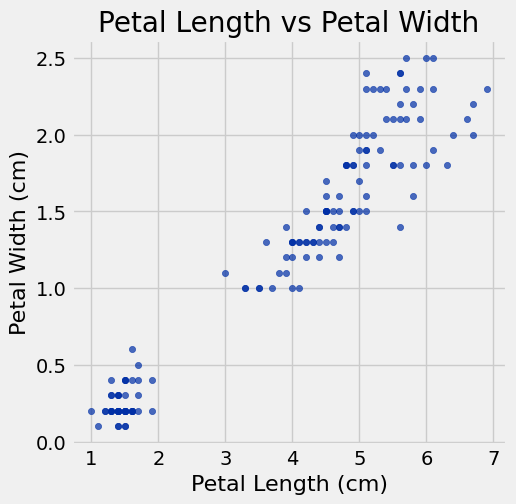

In [7]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis.
#     Add a title to your plot.

iris.scatter('petal_length', 'petal_width')
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

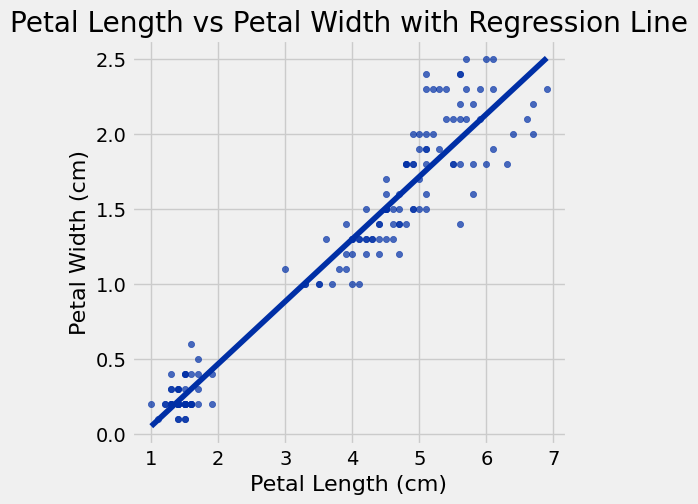

In [8]:
# Q5. Add a regression line to the scatter plot using fit_line=True.
#     Describe the pattern observed between the two variables.

iris.scatter('petal_length', 'petal_width', fit_line=True)
plt.title('Petal Length vs Petal Width with Regression Line')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

# Observation:
# There is a strong positive linear relationship between petal_length and petal_width.
# As petal length increases, petal width also increases consistently,
# and the data points cluster closely around the regression line,
# indicating that a linear model is a good fit for this relationship.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [9]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)

In [10]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))

In [11]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))

In [12]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))

In [13]:
# Q6. Compute and print the slope and intercept of the regression line
#     that predicts petal_width from petal_length. Write the full regression equation.

m = slope(iris, 'petal_length', 'petal_width')
b = intercept(iris, 'petal_length', 'petal_width')

print(f"Slope (m)    : {m:.4f}")
print(f"Intercept (b): {b:.4f}")
print()
print(f"Regression Equation: petal_width = {m:.4f} * petal_length + ({b:.4f})")

Slope (m)    : 0.4158
Intercept (b): -0.3631

Regression Equation: petal_width = 0.4158 * petal_length + (-0.3631)


In [14]:
# Q7. Use the regression equation to predict the petal width of a flower
#     with petal_length = 4.5 cm. Show your calculation.

petal_length_input = 4.5
predicted_width = m * petal_length_input + b

print(f"Calculation:")
print(f"  petal_width = {m:.4f} x {petal_length_input} + ({b:.4f})")
print(f"  petal_width = {m * petal_length_input:.4f} + ({b:.4f})")
print(f"  petal_width = {predicted_width:.4f} cm")

Calculation:
  petal_width = 0.4158 x 4.5 + (-0.3631)
  petal_width = 1.8709 + (-0.3631)
  petal_width = 1.5078 cm


In [15]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width.
#     Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

r = correlation(iris, 'petal_length', 'petal_width')
print(f"Correlation coefficient r = {r:.4f}")

# Interpretation:
# r ≈ 0.963 indicates a very strong positive linear relationship between
# petal_length and petal_width. As petal length increases, petal width
# increases almost proportionally. The value being very close to 1 confirms
# that a linear model is an excellent fit for this relationship.

Correlation coefficient r = 0.9629


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [16]:
# Q9. Compute predicted petal_width for every flower using the regression equation.
#     Add both the predicted values and residuals (actual - predicted) as new columns.
#     Display the first 8 rows.

# Compute predicted values for all 150 flowers
predicted = m * iris.column('petal_length') + b

# Compute residuals: actual minus predicted
residuals = iris.column('petal_width') - predicted

# Add both new columns to the table
iris = iris.with_columns(
    'predicted_petal_width', predicted,
    'residual', residuals
)

# Display first 8 rows
iris.show(8)

sepal_length,sepal_width,petal_length,petal_width,species,predicted_petal_width,residual
5.1,3.5,1.4,0.2,setosa,0.218982,-0.0189821
4.9,3,1.4,0.2,setosa,0.218982,-0.0189821
4.7,3.2,1.3,0.2,setosa,0.177407,0.0225935
4.6,3.1,1.5,0.2,setosa,0.260558,-0.0605576
5,3.6,1.4,0.2,setosa,0.218982,-0.0189821
5.4,3.9,1.7,0.4,setosa,0.343709,0.0562913
4.6,3.4,1.4,0.3,setosa,0.218982,0.0810179
5,3.4,1.5,0.2,setosa,0.260558,-0.0605576


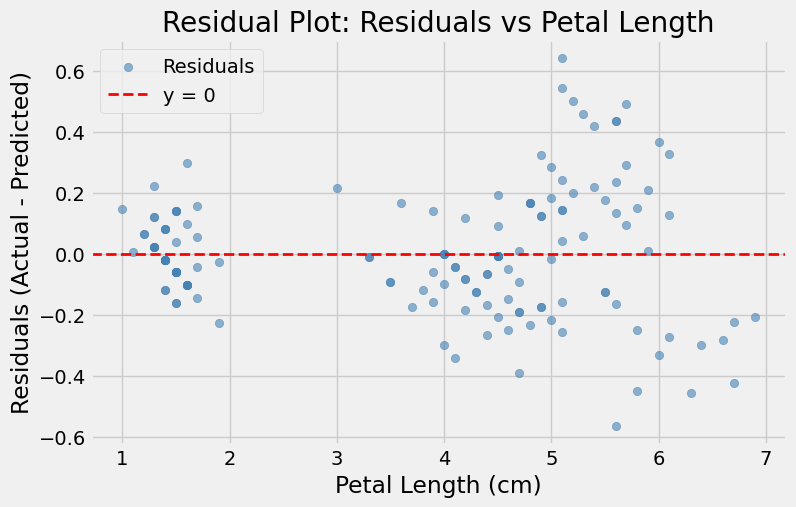

In [17]:
# Q10. Create a scatter plot of residuals (y-axis) vs petal_length (x-axis).
#      Add a horizontal red dashed line at y = 0.
#      Interpret what the plot tells us about how well the linear model fits the data.

plt.figure(figsize=(8, 5))
plt.scatter(iris.column('petal_length'), iris.column('residual'),
            color='steelblue', alpha=0.6, label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y = 0')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Residuals vs Petal Length')
plt.legend()
plt.show()

# Interpretation:
# The residuals are scattered roughly around the y = 0 line without a strong
# systematic curve or pattern, which suggests that the linear model is a
# reasonable fit for the overall data. However, there is slightly more spread
# in residuals for mid-range petal lengths (around 3-5 cm), which may reflect
# the influence of the three distinct species that naturally cluster separately
# within the dataset.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction.
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.